# Legal Clause Corpus — EDA

Exploratory analysis of the indexed clause corpus (Phase 3 output: ~317k labeled clauses, enriched with SIC industry code and exact filing date, in Elasticsearch). Reads directly from ES so this reflects the final, fully-enriched dataset rather than the pre-enrichment Parquet file.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from elasticsearch import Elasticsearch
from elasticsearch.helpers import scan

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

ES_HOST = "http://localhost:9200"
INDEX_NAME = "legal-clauses"

es = Elasticsearch(ES_HOST)
docs = [hit["_source"] for hit in scan(es, index=INDEX_NAME, query={"query": {"match_all": {}}})]
df = pd.DataFrame(docs)
print(df.shape)
df.head(3)

(317500, 15)


,clause_id,label,section_header,text,cik,company,form_type,file_type,accession,filename,filing_date,filing_year,sic,sic_description,text_len
0,c07b9d037d6566ba27b1f8de39b6f364e7179aba,Confidentiality,"4. NONCOMPETITION, NON-DISCLOSURE AND STOCK OWNERSHIP REQUIREMENTS.","(a) Employee acknowledges that her services are of a special, unique, extraordinary and intellectual character, and ...",1000045,NICHOLAS FINANCIAL INC,8-K,EX-10.1,0000950170-22-012923,nick-ex10_1.htm,2022-07-22,2022,6153,Short-Term Business Credit Institutions,6346
1,dc06327e59eb5ca26113ab95903ee632ba60879c,Termination,5. TERMINATION.,"(a) Death. The Employee’s employment hereunder shall terminate upon her death.\n(b) Disability. If, during the Term,...",1000045,NICHOLAS FINANCIAL INC,8-K,EX-10.1,0000950170-22-012923,nick-ex10_1.htm,2022-07-22,2022,6153,Short-Term Business Credit Institutions,14435
2,8480a8715cb85cffef6b2d45618b7e48f75e7385,Governing Law,16. GOVERNING LAW.,"(a) The validity, interpretation, construction and performance of this Agreement shall be governed by the internal l...",1000045,NICHOLAS FINANCIAL INC,8-K,EX-10.1,0000950170-22-012923,nick-ex10_1.htm,2022-07-22,2022,6153,Short-Term Business Credit Institutions,1107


## Overview: schema, nulls, duplicates

In [2]:
print("dtypes:\n", df.dtypes, "\n")
print("nulls per column:\n", df.isnull().sum(), "\n")
print("exact duplicate rows:", df.duplicated().sum())
print("duplicate (accession, filename, label, section_header):",
      df.duplicated(subset=["accession", "filename", "label", "section_header"]).sum())
print("unique filings:", df["accession"].nunique())
print("unique companies (CIK):", df["cik"].nunique())

dtypes:
 clause_id            str
label                str
section_header       str
text                 str
cik                  str
company              str
form_type            str
file_type            str
accession            str
filename             str
filing_date          str
filing_year          str
sic                  str
sic_description      str
text_len           int64
dtype: object 

nulls per column:
 clause_id             0
label                 0
section_header        0
text                  0
cik                   0
company               0
form_type             0
file_type             0
accession             0
filename              0
filing_date        2518
filing_year           0
sic                   0
sic_description       0
text_len              0
dtype: int64 



exact duplicate rows: 0
duplicate (accession, filename, label, section_header): 0
unique filings: 19815
unique companies (CIK): 5724


## Label distribution

The core question for the label-frequency gate: is every taxonomy category represented with enough volume for training/eval, and how imbalanced is the class distribution overall?

,count,pct
label,,
Payment Terms,78183,24.62
Termination,52434,16.51
Warranty/Representations,52309,16.48
Assignment,43237,13.62
Indemnification,31376,9.88
Governing Law,27442,8.64
Confidentiality,20493,6.45
Dispute Resolution/Arbitration,7002,2.21
Limitation of Liability,3440,1.08


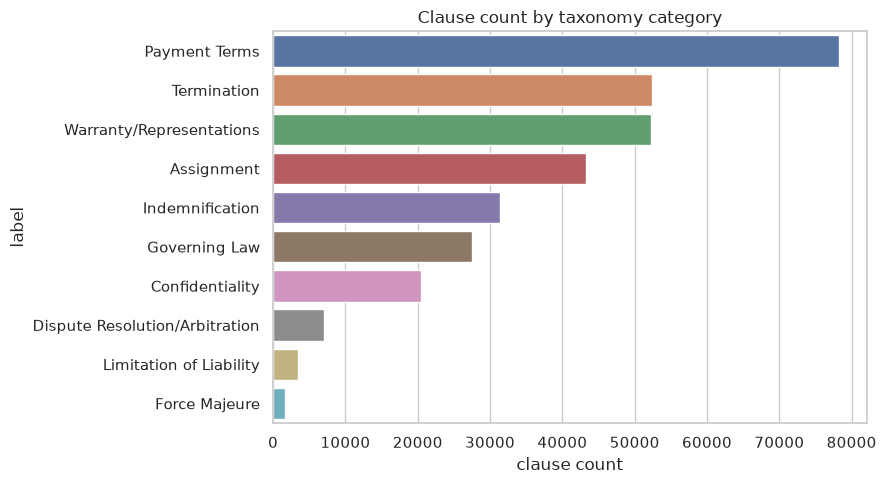

imbalance ratio (largest / smallest): 49.4x


In [3]:
label_counts = df["label"].value_counts()
display(label_counts.to_frame("count").assign(pct=lambda d: (100 * d["count"] / d["count"].sum()).round(2)))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, legend=False, ax=ax)
ax.set_xlabel("clause count")
ax.set_title("Clause count by taxonomy category")
plt.tight_layout()
plt.show()

print(f"imbalance ratio (largest / smallest): {label_counts.max() / label_counts.min():.1f}x")

## Clause length distribution

Length (in characters, as a proxy for token count) matters directly for Phase 5's LoRA context window budget, and per-category outliers are worth knowing about before curating the training set.

count    317500.000000
mean        989.868117
std        1490.042120
min          30.000000
25%         233.000000
50%         514.000000
75%        1163.000000
max       60561.000000
Name: text_len, dtype: float64

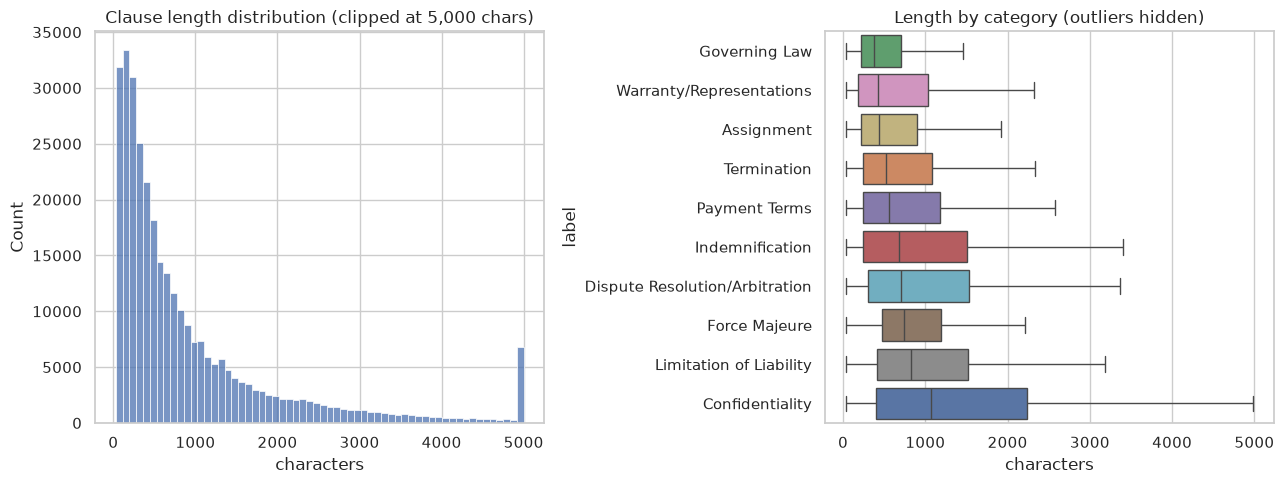

clauses > 10,000 chars: 1204 (0.38%)


In [4]:
df["text_len"] = df["text"].str.len()
display(df["text_len"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["text_len"].clip(upper=5000), bins=60, ax=axes[0])
axes[0].set_title("Clause length distribution (clipped at 5,000 chars)")
axes[0].set_xlabel("characters")

order = df.groupby("label")["text_len"].median().sort_values().index
sns.boxplot(data=df, x="text_len", y="label", order=order, hue="label", legend=False, ax=axes[1], showfliers=False)
axes[1].set_title("Length by category (outliers hidden)")
axes[1].set_xlabel("characters")
plt.tight_layout()
plt.show()

print("clauses > 10,000 chars:", (df["text_len"] > 10000).sum(),
      f"({100 * (df['text_len'] > 10000).mean():.2f}%)")

## Company (CIK) concentration

Directly motivates Phase 4's CIK-based train/val/test split: if a handful of filers (e.g. securitization shelf issuers with dozens of near-identical exhibits) dominate the clause count, splitting by individual clause instead of by company would leak near-duplicate boilerplate across splits.

,clause_count
company,
SANTANDER DRIVE AUTO RECEIVABLES LLC,1081
Sunnova Energy International Inc.,983
HERTZ CORP,812
MANUFACTURED HOUSING PROPERTIES INC.,751
ProFrac Holding Corp.,673
FORD CREDIT AUTO RECEIVABLES TWO LLC,606
Regional Management Corp.,579
"EFCAR, LLC",564
Presto Automation Inc.,547


median clauses/company: 37.0


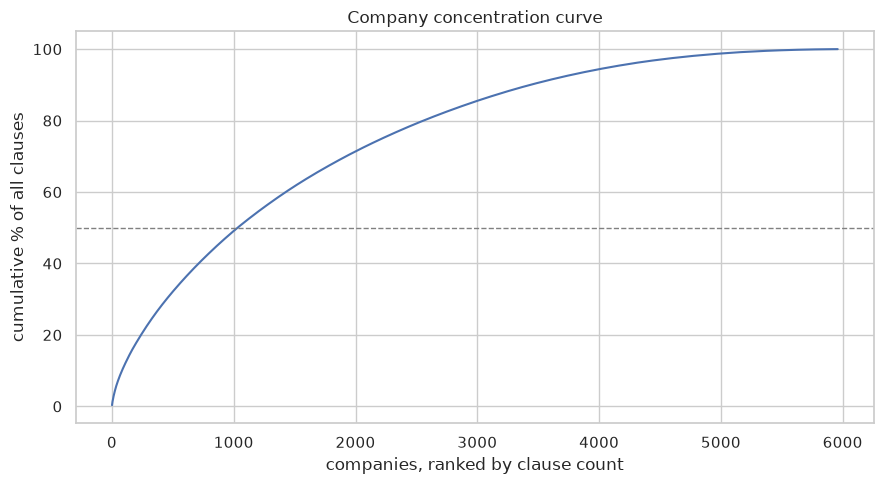

top 1032 companies (17.3% of all companies) account for 50% of all clauses


In [5]:
by_company = df.groupby("company").size().sort_values(ascending=False)
display(by_company.head(10).to_frame("clause_count"))
print("median clauses/company:", by_company.median())

cum_share = (by_company.cumsum() / by_company.sum() * 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_share) + 1), cum_share.values)
ax.set_xlabel("companies, ranked by clause count")
ax.set_ylabel("cumulative % of all clauses")
ax.set_title("Company concentration curve")
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

n_for_half = (cum_share <= 50).sum() + 1
print(f"top {n_for_half} companies ({100*n_for_half/len(by_company):.1f}% of all companies) "
      f"account for 50% of all clauses")

## Form type, filing year, and label x form_type cross-tab

Sanity check that metadata joined in cleanly and that label distribution isn't a pure artifact of one form type dominating.

In [6]:
print(df["form_type"].value_counts(), "\n")
print(df["filing_year"].value_counts().sort_index(), "\n")

cross = pd.crosstab(df["label"], df["form_type"], normalize="index").round(2)
display(cross)

form_type
8-K     184213
10-Q     81777
10-K     39323
S-1      12187
Name: count, dtype: int64 

filing_year
2022     96690
2023    220810
Name: count, dtype: int64 



form_type,10-K,10-Q,8-K,S-1
label,,,,
Assignment,0.11,0.25,0.61,0.03
Confidentiality,0.15,0.31,0.49,0.05
Dispute Resolution/Arbitration,0.19,0.32,0.44,0.05
Force Majeure,0.16,0.35,0.42,0.07
Governing Law,0.16,0.30,0.50,0.04
Indemnification,0.10,0.22,0.64,0.05
Limitation of Liability,0.10,0.23,0.62,0.04
Payment Terms,0.12,0.28,0.57,0.03
Termination,0.17,0.29,0.50,0.04


## Phase 3 enrichment coverage: SIC code & filing date

Confirms the metadata backfill actually joined in cleanly across the full corpus, not just the sample checked at indexing time.

In [7]:
missing_sic = (df["sic"].isnull() | (df["sic"].isin(["", "0000"]))).sum()
missing_date = df["filing_date"].isnull().sum()
print(f"missing/unclassified sic: {missing_sic} ({100*missing_sic/len(df):.2f}%)")
print(f"missing filing_date: {missing_date} ({100*missing_date/len(df):.2f}%)")

# For rows missing filing_date, filing_year should still be there as a fallback.
still_missing_year = df.loc[df["filing_date"].isnull(), "filing_year"].isnull().sum()
print(f"of those missing filing_date, missing filing_year fallback too: {still_missing_year}")

# SEC genuinely doesn't assign SIC codes to certain entity types (e.g. Business
# Development Companies like Gladstone Capital, Ares Capital) - not a pipeline
# bug, but isnull() alone misses it since SEC returns "" rather than null.
print("\nsample companies with no SIC classification:")
print(df.loc[df["sic"].isin(["", "0000"]), "company"].drop_duplicates().head(5).tolist())

missing/unclassified sic: 11176 (3.52%)
missing filing_date: 2518 (0.79%)
of those missing filing_date, missing filing_year fallback too: 0

sample companies with no SIC classification:
['GLADSTONE CAPITAL CORP', 'MidCap Financial Investment Corp', 'Hercules Capital, Inc.', 'PROSPECT CAPITAL CORP', 'ARES CAPITAL CORP']


## Industry (SIC) distribution

A dimension that wasn't checkable before Phase 3: is the corpus reasonably diverse across industries, or dominated by one or two sectors (e.g. the auto-loan securitization filers we already spotted via company concentration)?

unique industries (SIC descriptions, excluding unclassified): 317


,clause_count,pct
sic_description,,
Pharmaceutical Preparations,35534,11.19
Real Estate Investment Trusts,13878,4.37
Services-Prepackaged Software,11033,3.47
"Biological Products, (No Diagnostic Substances)",10364,3.26
Surgical & Medical Instruments & Apparatus,9436,2.97
Asset-Backed Securities,7992,2.52
Finance Services,7501,2.36
Blank Checks,7398,2.33
Crude Petroleum & Natural Gas,6545,2.06


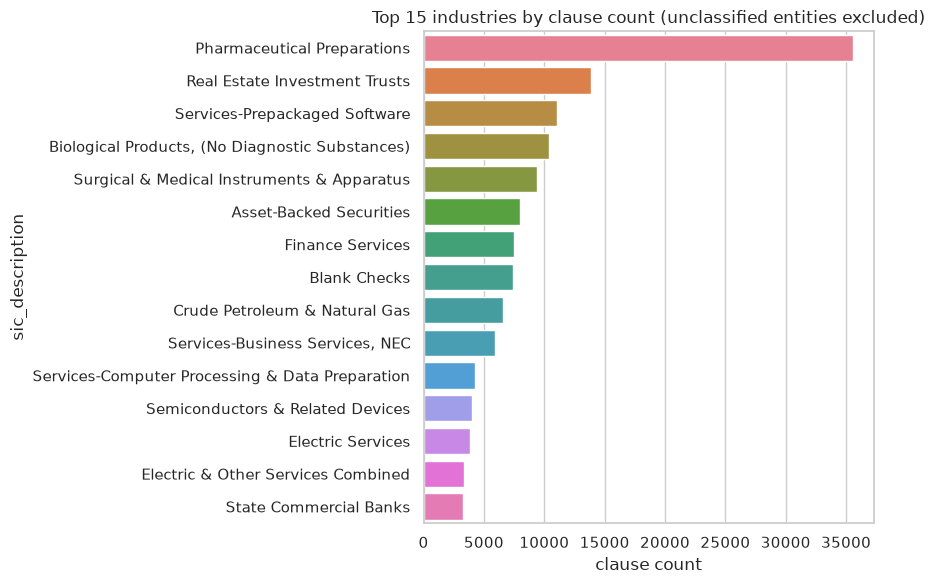

top 10 industries account for 36.4% of all clauses


In [8]:
sic_counts = df.loc[~df["sic"].isin(["", "0000"]), "sic_description"].value_counts()
print("unique industries (SIC descriptions, excluding unclassified):", sic_counts.nunique())
display(sic_counts.head(15).to_frame("clause_count").assign(
    pct=lambda d: (100 * d["clause_count"] / len(df)).round(2)
))

fig, ax = plt.subplots(figsize=(9, 6))
top15 = sic_counts.head(15)
sns.barplot(x=top15.values, y=top15.index, hue=top15.index, legend=False, ax=ax)
ax.set_xlabel("clause count")
ax.set_title("Top 15 industries by clause count (unclassified entities excluded)")
plt.tight_layout()
plt.show()

top10_pct = 100 * sic_counts.head(10).sum() / len(df)
print(f"top 10 industries account for {top10_pct:.1f}% of all clauses")

## Spot-check: a few random examples per category

A qualitative gut-check to sit alongside all the quantitative stats above — reading actual clause text is still the fastest way to catch a labeling problem the numbers wouldn't surface.

In [9]:
for label in df["label"].unique():
    sample = df[df["label"] == label].sample(1, random_state=1).iloc[0]
    print(f"=== [{label}] {sample['company']} | header={sample['section_header']!r} ===")
    print(sample["text"][:300])
    print()

=== [Confidentiality] Edwards Lifesciences Corp | header='Confidentiality' ===
. The Administrative Agent and each Lender agrees to
maintain the confidentiality of the Information (as defined below), except that Information may be disclosed (a) to its and its Affiliates’ directors, officers, employees, trustees and agents, including accountants, legal counsel and other
advisor

=== [Termination] INTERNATIONAL FLAVORS & FRAGRANCES INC | header='Termination or Reduction of the Commitments' ===
. (a) The Company shall have the right, upon at least two Business
Days’ notice to the Agent, to terminate in whole or permanently reduce ratably in part the Unused Commitments of the Lenders;
provided
that each partial reduction (x) shall be in the minimum aggregate amount of $10,000,000 or an
inte

=== [Governing Law] ADTRAN Holdings, Inc. | header='Governing Law' ===
. The Plan shall be interpreted, construed and administered in accordance with the laws of the State of Alabama,
without giving ef